# Stability Study: Weight and PIER Robustness

This notebook probes how DISCO and related baselines respond to small, realistic perturbations.
We resample anchors, drop probes and peers, sweep hyperparameters, and flip the anchor space to
quantify stability of learned weights and PIER curves across multiple seeds, interventions, and queries.

## Experiment Outline

1. Build synthetic scenarios across several seeds and train surrogate devices.
2. For each query/intervention pair, record baseline weights and PIER curves for DISCO, Top-K, global matching, and uniform averaging.
3. Apply five stressors (100 replicates each) spanning anchor bootstrap, probe subsampling, peer dropout, hyperparameter sweeps, and anchor-space flips.
4. Track weight L1 swing, effective sample size, entropy, PIER AUC/MaxAbs statistics, curve correlations, and top-peer overlap per replicate.
5. Summarise stability with boxplots, coefficient-of-variation tables, and stress-response curves vs. \lambda and K.

In [52]:
# Add repository root to the Python path so relative imports resolve
import sys, os
ROOT = os.path.abspath(os.path.join('..', '..'))
if ROOT not in sys.path:
    sys.path.append(ROOT)


In [53]:
import copy
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from disco.synth.generator import create_scenario
from disco.explain.disco_algorithm import DiscoRunner
from disco.explain.baselines import BaselineRunner
from disco.counterfactual.pmode import PModeCounterfactual
from disco.counterfactual.smode import SModeCounterfactual
from disco.cli.main import compute_probe_trajectories
from disco.devices.sklearn_tabular import SklearnDevice
from disco.interventions.tabular import FeatureAdd, FeatureScale, ClampedShift
from disco.interventions.grids import Grids
from disco.anchors.knn import AnchorSelector, AnchorSelection
from disco.matching.weights import WeightSolver, MatchInputs
from disco.data.loaders import stack_prewindow

plt.style.use('seaborn-v0_8')
pd.options.display.float_format = '{:,.4f}'.format


In [54]:
# Core configuration (tweak as needed for runtime vs. fidelity)
GLOBAL_SEEDS = [0, 11]
N_REPLICATES_PER_STRESSOR = 100
N_QUERY_POINTS = 16

P = 20                   # feature dimension
N_DEVICES = 12            # total devices (target + peers)
M_PROBE = 900             # probe rows for trajectory estimation
N_TRAIN_SAMPLES = 5000    # per-device training points

TARGET_IDX = 0
TARGET_CLASS = 0
MODE = 's'                # DISCO mode

BASE_ANCHOR_K = 20
BASE_ANCHOR_TAU = 0.3
BASE_LAMBDA = 0.01

ANCHOR_TAU_JITTER = 0.10  # �10% jitter for bootstrap stressor
PROBE_DROP_FRAC = 0.10
TRAJECTORY_NOISE_STD = 0.05
TOP_PEER_K = 5            # influential peer overlap metric
TOPK_NEIGHBORS = 5        # Top-K baseline uses this many peers when possible

HYPERPARAM_LAMBDAS = [0.0, 0.005, 0.01, 0.05]
HYPERPARAM_K = [8, 12, 16]

METHODS = ['DISCO', 'TopK', 'AVG', 'Ridge']
STRESSORS = ['anchor_bootstrap', 'probe_subsample', 'peer_dropout', 'hyperparams', 'anchor_space', 'trajectory_noise']
STRESSOR_LABELS = {
    'anchor_bootstrap': 'Anchor bootstrap',
    'probe_subsample': 'Probe subsample',
    'peer_dropout': 'Peer dropout',
    'hyperparams': 'Hyperparam sweep',
    'anchor_space': 'Feature-space anchors',
    'trajectory_noise': 'Trajectory noise',
}

print(f'Seeds: {GLOBAL_SEEDS}')
print(f'Stressors: {list(STRESSOR_LABELS.values())}')


Seeds: [0, 11]
Stressors: ['Anchor bootstrap', 'Probe subsample', 'Peer dropout', 'Hyperparam sweep', 'Feature-space anchors', 'Trajectory noise']


In [55]:
class BootstrapAnchorSelector(AnchorSelector):
    """Anchor selector that perturbs tau and bootstraps anchors with replacement."""

    def __init__(self, *, tau_jitter: float = 0.1, resample: bool = True, rng: Optional[int] = None, **kwargs):
        super().__init__(**kwargs)
        self.tau_jitter = tau_jitter
        self.resample = resample
        if isinstance(rng, np.random.RandomState):
            self._rng = rng
        else:
            self._rng = np.random.RandomState(rng) if rng is not None else None

    def _random(self) -> np.random.RandomState:
        return self._rng if self._rng is not None else np.random.mtrand._rand

    def select(self, X_probe: np.ndarray, x_star: np.ndarray) -> AnchorSelection:
        original_tau = self.tau
        if self.tau_jitter:  # jitter tau multiplicatively within �jitter
            scale = 1.0 + self._random().uniform(-self.tau_jitter, self.tau_jitter)
            self.tau = max(1e-6, original_tau * scale)
        selection = super().select(X_probe, x_star)
        self.tau = original_tau

        if self.resample and selection.indices.size:
            rng = self._random()
            boot_idx = rng.choice(len(selection.indices), size=len(selection.indices), replace=True)
            unique, counts = np.unique(boot_idx, return_counts=True)
            new_indices = selection.indices[unique]
            new_distances = selection.distances[unique]
            weights = counts.astype(float)
            weights /= weights.sum()
            selection = AnchorSelection(indices=new_indices, weights=weights, distances=new_distances)
        else:
            if selection.weights.sum() <= 0:
                weights = np.ones_like(selection.weights) / len(selection.weights)
                selection = AnchorSelection(indices=selection.indices, weights=weights, distances=selection.distances)
        return selection


def make_interventions(theta_post: np.ndarray) -> List:
    max_intensity = float(np.max(theta_post))
    return [
        FeatureAdd(feat_idx=0, delta_max=max_intensity, name='intensity_shift'),
        FeatureAdd(feat_idx=1, delta_max=1.8, name='add_f1'),
        FeatureScale(feat_idx=2, scale_max=0.6, name='scale_f2'),
        ClampedShift(feat_idx=3, shift_max=1.5, lower=-2.5, upper=2.5, name='clamped_f3'),
    ]


def train_model_devices(scenario, n_samples: int, seed: int) -> List[SklearnDevice]:
    rng = np.random.RandomState(seed)
    devices = []
    from sklearn.neural_network import MLPRegressor
    for idx, device in enumerate(scenario.devices):
        local_seed = rng.randint(0, 2**31 - 1)
        X, y = scenario.sample_dataset(idx, n_samples, np.random.RandomState(local_seed))
        mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=400, early_stopping=True, random_state=local_seed)
        mlp.fit(X, y)
        devices.append(SklearnDevice(id=device.id, model=mlp, task='regression', scalarization='identity'))
    return devices


def select_queries(X_probe: np.ndarray, n_queries: int, seed: int, extra_point: Optional[np.ndarray] = None) -> List[Tuple[str, np.ndarray]]:
    rng = np.random.RandomState(seed)
    m = len(X_probe)
    n_select = min(n_queries, m)
    indices = rng.choice(m, size=n_select, replace=False) if n_select < m else np.arange(m)
    queries = [(f'probe_{int(idx)}', X_probe[int(idx): int(idx) + 1]) for idx in indices]
    if extra_point is not None:
        queries.append(('x_star', np.atleast_2d(extra_point)))
    return queries


def align_weights(raw_weights: np.ndarray, peer_ids_current: List[str], peer_ids_base: List[str]) -> np.ndarray:
    aligned = np.zeros(len(peer_ids_base), dtype=float)
    index_map = {pid: i for i, pid in enumerate(peer_ids_base)}
    for weight, pid in zip(raw_weights, peer_ids_current):
        if pid in index_map:
            aligned[index_map[pid]] = weight
    return aligned


def effective_sample_size(weights: np.ndarray, eps: float = 1e-12) -> float:
    denom = np.sum(np.square(weights))
    if denom <= eps:
        return 0.0
    total = np.sum(weights)
    return (total ** 2) / (denom + eps)


def weight_entropy(weights: np.ndarray, eps: float = 1e-12) -> float:
    positive = np.clip(weights, eps, None)
    return float(-np.sum(positive * np.log(positive)))


def top_peer_set(weights: np.ndarray, peer_ids_base: List[str], k: int) -> set:
    if weights.size == 0 or k <= 0:
        return set()
    k = min(k, weights.size)
    top_idx = np.argsort(weights)[-k:]
    return {peer_ids_base[idx] for idx in top_idx if weights[idx] > 0}


def jaccard(a: set, b: set) -> float:
    if not a and not b:
        return 1.0
    if not a or not b:
        return 0.0
    inter = len(a & b)
    union = len(a | b)
    return inter / union if union else 0.0


def subsample_probes(X_probe: np.ndarray, traj_model: Dict, traj_oracle: Dict, drop_frac: float, rng: np.random.RandomState):
    if drop_frac <= 0:
        return X_probe, traj_model, traj_oracle
    m = len(X_probe)
    drop = int(np.ceil(drop_frac * m))
    if drop <= 0 or drop >= m:
        return X_probe, traj_model, traj_oracle
    keep_idx = np.sort(np.setdiff1d(np.arange(m), rng.choice(m, size=drop, replace=False)))
    X_new = X_probe[keep_idx]
    traj_model_new = {(k0, k1): v[keep_idx] for (k0, k1), v in traj_model.items()}
    traj_oracle_new = {(k0, k1): v[keep_idx] for (k0, k1), v in traj_oracle.items()}
    return X_new, traj_model_new, traj_oracle_new


def drop_peer(devices: List[SklearnDevice], traj_model: Dict, traj_oracle: Dict, peer_id: str, target_id: str) -> Tuple[List[SklearnDevice], Dict, Dict]:
    new_devices = [d for d in devices if d.id != peer_id]
    if target_id not in {d.id for d in new_devices}:
        raise ValueError('Target device dropped during peer dropout stressor')
    traj_model_new = {(dev, interv): mat for (dev, interv), mat in traj_model.items() if dev != peer_id}
    traj_oracle_new = {(dev, interv): mat for (dev, interv), mat in traj_oracle.items() if dev != peer_id}
    return new_devices, traj_model_new, traj_oracle_new


def safe_corr(a: np.ndarray, b: np.ndarray) -> float:
    if a.size == 0 or b.size == 0:
        return np.nan
    if np.allclose(a, a[0]) or np.allclose(b, b[0]):
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])


@dataclass
class SeedContext:
    seed: int
    scenario: any
    model_devices: List[SklearnDevice]
    trajectories_model: Dict
    trajectories_oracle: Dict
    grids: Grids
    X_probe: np.ndarray
    peer_ids: List[str]
    interventions: List
    queries: List[Tuple[str, np.ndarray]]

baseline_runner = BaselineRunner()
pmode_builder = PModeCounterfactual()
smode_builder = SModeCounterfactual()
weight_solver = WeightSolver(method='projected_grad', max_iter=1000)


def run_disco(devices: List[SklearnDevice], x_star: np.ndarray, X_probe: np.ndarray, trajectories: Dict, grids: Grids, intervention, lam: float, anchor_selector, anchor_space: str):
    runner = DiscoRunner(mode=MODE, lam=lam, anchor_selector=anchor_selector)
    return runner.run(
        devices=devices,
        target_idx=TARGET_IDX,
        x_star=x_star,
        X_probe=X_probe,
        trajectories=trajectories,
        grids=grids,
        intervention=intervention,
        target_class=TARGET_CLASS,
        anchor_space=anchor_space
    )


def run_topk(devices: List[SklearnDevice], trajectories: Dict, anchor_sel: AnchorSelection, grids: Grids, intervention, x_star: np.ndarray):
    output = baseline_runner.baseline_topk_avg(
        devices=devices,
        trajectories=trajectories,
        anchor_sel=anchor_sel,
        theta0=grids.theta0,
        x_star=x_star,
        grids=grids,
        intervention=intervention,
        target_idx=TARGET_IDX,
        Kp=min(TOPK_NEIGHBORS, len(devices) - 1),
        target_class=TARGET_CLASS
    )
    peer_ids_current = [d.id for d in devices if d.id != devices[TARGET_IDX].id]
    selected = output.meta.get('selected_peers', [])
    weights = np.zeros(len(peer_ids_current), dtype=float)
    if selected:
        val = 1.0 / len(selected)
        for pid in selected:
            if pid in peer_ids_current:
                weights[peer_ids_current.index(pid)] = val
    return weights, output.tau, set(selected)


def run_avg(devices: List[SklearnDevice], grids: Grids, intervention, x_star: np.ndarray):
    peer_ids_current = [d.id for d in devices if d.id != devices[TARGET_IDX].id]
    n_peers = len(peer_ids_current)
    weights = np.ones(n_peers, dtype=float) / n_peers if n_peers else np.array([], dtype=float)
    output = baseline_runner.baseline_avg(
        devices=devices,
        x_star=x_star,
        grids=grids,
        intervention=intervention,
        target_idx=TARGET_IDX,
        target_class=TARGET_CLASS
    )
    return weights, output.tau


def run_global(devices: List[SklearnDevice], trajectories: Dict, grids: Grids, intervention, x_star: np.ndarray, lam: float):
    target_device = devices[TARGET_IDX]
    target_key = (target_device.id, intervention.name)
    if target_key not in trajectories:
        raise ValueError(f'Missing trajectories for {target_key}')
    m = trajectories[target_key].shape[0]
    global_sel = AnchorSelection(indices=np.arange(m), weights=np.ones(m) / m, distances=np.zeros(m))
    y_t_pre, X_peers_pre = stack_prewindow(trajectories, target_device, devices, global_sel, intervention, grids.theta0)
    match_inputs = MatchInputs(y_t=y_t_pre, X_peers=X_peers_pre, lam=lam)
    result = weight_solver.solve(match_inputs)
    weights = result.w
    y_syn = smode_builder.build(weights, devices, x_star, grids, intervention, target_device, TARGET_CLASS)
    y_t = np.zeros(len(grids.theta))
    for i, theta in enumerate(grids.theta):
        x_theta = intervention.apply(x_star, theta)
        raw = target_device.predict_raw(x_theta)
        y_t[i] = target_device.g(raw, TARGET_CLASS)[0]
    tau = y_t - y_syn
    return weights, tau

def prepare_seed_context(seed: int) -> SeedContext:
    rng = np.random.RandomState(seed)
    scenario_seed = rng.randint(0, 2**31 - 1)
    model_seed = rng.randint(0, 2**31 - 1)
    query_seed = rng.randint(0, 2**31 - 1)

    scenario = create_scenario(
        p=P,
        N=N_DEVICES,
        alpha_target=0.8,
        theta0=np.array([0.0, 0.25, 0.5, 0.75]),
        theta_post=np.array([1.0, 1.2, 1.4, 1.6, 1.8]),
        m_probe=M_PROBE,
        rng=np.random.RandomState(scenario_seed),
        base_jitter=0.5,
        peer_alpha_std=0.3,
        noise_std=0.05
    )
    interventions = make_interventions(scenario.theta)
    model_devices = train_model_devices(scenario, N_TRAIN_SAMPLES, model_seed)

    trajectories_model = compute_probe_trajectories(
        devices=model_devices,
        X_probe=scenario.X_probe,
        interventions=interventions,
        theta0=scenario.theta0,
        dp_noise_std=0.0,
        seed=seed,
        target_class=TARGET_CLASS
    )
    trajectories_oracle = compute_probe_trajectories(
        devices=scenario.devices,
        X_probe=scenario.X_probe,
        interventions=interventions,
        theta0=scenario.theta0,
        dp_noise_std=0.0,
        seed=seed,
        target_class=TARGET_CLASS
    )

    grids = Grids(theta0=scenario.theta0, theta=scenario.theta)
    peer_ids = [d.id for d in model_devices if d.id != model_devices[TARGET_IDX].id]
    queries = select_queries(scenario.X_probe, N_QUERY_POINTS, query_seed, extra_point=scenario.x_star)

    return SeedContext(seed, scenario, model_devices, trajectories_model, trajectories_oracle, grids, scenario.X_probe, peer_ids, interventions, queries)




def compute_base_cache(ctx: SeedContext) -> Dict[Tuple[str, str], Dict]:
    base_cache: Dict[Tuple[str, str], Dict] = {}
    for query_label, x_star in ctx.queries:
        for intervention in ctx.interventions:
            anchor_selector = AnchorSelector(K=min(BASE_ANCHOR_K, len(ctx.X_probe)), tau=BASE_ANCHOR_TAU)
            disco_output = run_disco(
                devices=ctx.model_devices,
                x_star=x_star,
                X_probe=ctx.X_probe,
                trajectories=ctx.trajectories_model,
                grids=ctx.grids,
                intervention=intervention,
                lam=BASE_LAMBDA,
                anchor_selector=anchor_selector,
                anchor_space='response'
            )
            te_output = disco_output.te_output
            anchor_sel = disco_output.diagnostics.get('anchor_selection')
            peer_ids_current = [d.id for d in ctx.model_devices if d.id != ctx.model_devices[TARGET_IDX].id]

            disco_weights = align_weights(disco_output.weights, peer_ids_current, ctx.peer_ids)
            topk_weights_raw, topk_tau, _ = run_topk(ctx.model_devices, ctx.trajectories_model, anchor_sel, ctx.grids, intervention, x_star)
            topk_weights = align_weights(topk_weights_raw, peer_ids_current, ctx.peer_ids)

            avg_weights_raw, avg_tau = run_avg(ctx.model_devices, ctx.grids, intervention, x_star)
            avg_weights = align_weights(avg_weights_raw, peer_ids_current, ctx.peer_ids)

            global_weights_raw, global_tau = run_global(ctx.model_devices, ctx.trajectories_model, ctx.grids, intervention, x_star, BASE_LAMBDA)
            global_weights = align_weights(global_weights_raw, peer_ids_current, ctx.peer_ids)

            ridge_output = baseline_runner.baseline_unconstrained_ridge(
                devices=ctx.model_devices,
                trajectories=ctx.trajectories_model,
                anchor_sel=anchor_sel,
                theta0=ctx.grids.theta0,
                x_star=x_star,
                grids=ctx.grids,
                intervention=intervention,
                target_idx=TARGET_IDX,
                lam=BASE_LAMBDA,
                target_class=TARGET_CLASS,
            )
            ridge_weights_raw = ridge_output.meta.get('w_clipped', np.zeros(len(peer_ids_current), dtype=float))
            ridge_weights = align_weights(ridge_weights_raw, peer_ids_current, ctx.peer_ids)

            method_entries = {
                'DISCO': {
                    'weights': disco_weights,
                    'tau': te_output.tau,
                    'top_peers': top_peer_set(disco_weights, ctx.peer_ids, TOP_PEER_K),
                },
                'TopK': {
                    'weights': topk_weights,
                    'tau': topk_tau,
                    'top_peers': top_peer_set(topk_weights, ctx.peer_ids, TOP_PEER_K),
                },
                'AVG': {
                    'weights': avg_weights,
                    'tau': avg_tau,
                    'top_peers': top_peer_set(avg_weights, ctx.peer_ids, TOP_PEER_K),
                },
                'Global': {
                    'weights': global_weights,
                    'tau': global_tau,
                    'top_peers': top_peer_set(global_weights, ctx.peer_ids, TOP_PEER_K),
                },
                'Ridge': {
                    'weights': ridge_weights,
                    'tau': ridge_output.tau,
                    'top_peers': top_peer_set(ridge_weights, ctx.peer_ids, TOP_PEER_K),
                },
            }

            base_cache[(query_label, intervention.name)] = {
                'theta': ctx.grids.theta,
                'anchor_selection': anchor_sel,
                'methods': method_entries,
                'x_star': x_star,
            }
    return base_cache


In [56]:

def build_perturbation(ctx: SeedContext, stressor: str, rng: np.random.RandomState, base_entry: Dict) -> Optional[Dict]:
    pert: Dict[str, any] = {
        'anchor_space': 'response',
        'lam': BASE_LAMBDA,
        'model_devices': ctx.model_devices,
        'trajectories_model': ctx.trajectories_model,
        'trajectories_oracle': ctx.trajectories_oracle,
        'X_probe': ctx.X_probe,
        'meta': {},
    }
    current_K = min(BASE_ANCHOR_K, len(pert['X_probe']))

    if stressor == 'anchor_bootstrap':
        pert['anchor_selector_factory'] = lambda: BootstrapAnchorSelector(
            K=current_K,
            tau=BASE_ANCHOR_TAU,
            tau_jitter=ANCHOR_TAU_JITTER,
            rng=rng.randint(0, 2**31 - 1),
        )
    elif stressor == 'probe_subsample':
        X_new, traj_model_new, traj_oracle_new = subsample_probes(
            pert['X_probe'],
            pert['trajectories_model'],
            pert['trajectories_oracle'],
            PROBE_DROP_FRAC,
            rng,
        )
        if len(X_new) == 0:
            return None
        pert['X_probe'] = X_new
        pert['trajectories_model'] = traj_model_new
        pert['trajectories_oracle'] = traj_oracle_new
        current_K = min(BASE_ANCHOR_K, len(X_new))
        pert['anchor_selector_factory'] = lambda: AnchorSelector(K=current_K, tau=BASE_ANCHOR_TAU)
        pert['meta']['probe_fraction'] = len(X_new) / len(ctx.X_probe)
    elif stressor == 'peer_dropout':
        base_weights = base_entry['methods']['DISCO']['weights']
        if np.sum(base_weights) > 0 and rng.rand() < 0.5:
            drop_idx = int(np.argmax(base_weights))
        else:
            drop_idx = rng.randint(0, len(ctx.peer_ids))
        peer_id = ctx.peer_ids[drop_idx]
        new_devices, traj_model_new, traj_oracle_new = drop_peer(
            pert['model_devices'],
            pert['trajectories_model'],
            pert['trajectories_oracle'],
            peer_id,
            pert['model_devices'][TARGET_IDX].id,
        )
        pert['model_devices'] = new_devices
        pert['trajectories_model'] = traj_model_new
        pert['trajectories_oracle'] = traj_oracle_new
        current_K = min(BASE_ANCHOR_K, len(pert['X_probe']))
        pert['anchor_selector_factory'] = lambda: AnchorSelector(K=current_K, tau=BASE_ANCHOR_TAU)
        pert['meta']['peer_dropped'] = peer_id
    elif stressor == 'hyperparams':
        lam_choice = float(rng.choice(HYPERPARAM_LAMBDAS))
        k_choice = int(rng.choice(HYPERPARAM_K))
        current_K = min(k_choice, len(pert['X_probe']))
        pert['lam'] = lam_choice
        pert['anchor_selector_factory'] = lambda: AnchorSelector(K=current_K, tau=BASE_ANCHOR_TAU)
        pert['meta']['lambda'] = lam_choice
        pert['meta']['K'] = k_choice
    elif stressor == 'anchor_space':
        pert['anchor_space'] = 'features'
        pert['anchor_selector_factory'] = lambda: AnchorSelector(K=current_K, tau=BASE_ANCHOR_TAU)
    elif stressor == 'trajectory_noise':
        def add_noise(traj_dict):
            return {key: value + rng.normal(scale=TRAJECTORY_NOISE_STD, size=value.shape) for key, value in traj_dict.items()}
        pert['trajectories_model'] = add_noise(pert['trajectories_model'])
        pert['trajectories_oracle'] = add_noise(pert['trajectories_oracle'])
        pert['anchor_selector_factory'] = lambda: AnchorSelector(K=current_K, tau=BASE_ANCHOR_TAU)
        pert['meta']['noise_std'] = TRAJECTORY_NOISE_STD
    else:
        pert['anchor_selector_factory'] = lambda: AnchorSelector(K=current_K, tau=BASE_ANCHOR_TAU)

    if len(pert['X_probe']) == 0:
        return None
    return pert


def run_methods(ctx: SeedContext, pert: Dict, x_star: np.ndarray, intervention, peer_ids_base: List[str]) -> Dict[str, Dict]:
    devices = pert['model_devices']
    trajectories_model = pert['trajectories_model']
    X_probe = pert['X_probe']
    lam = pert['lam']
    anchor_space = pert['anchor_space']
    anchor_selector = pert['anchor_selector_factory']()

    disco_output = run_disco(
        devices=devices,
        x_star=x_star,
        X_probe=X_probe,
        trajectories=trajectories_model,
        grids=ctx.grids,
        intervention=intervention,
        lam=lam,
        anchor_selector=anchor_selector,
        anchor_space=anchor_space,
    )
    te_output = disco_output.te_output
    anchor_sel = disco_output.diagnostics.get('anchor_selection')
    peer_ids_current = [d.id for d in devices if d.id != devices[TARGET_IDX].id]

    results: Dict[str, Dict] = {}

    disco_weights = align_weights(disco_output.weights, peer_ids_current, peer_ids_base)
    results['DISCO'] = {
        'weights': disco_weights,
        'tau': te_output.tau,
        'anchor_sel': anchor_sel,
    }

    topk_weights_raw, topk_tau, _ = run_topk(devices, trajectories_model, anchor_sel, ctx.grids, intervention, x_star)
    topk_weights = align_weights(topk_weights_raw, peer_ids_current, peer_ids_base)
    results['TopK'] = {
        'weights': topk_weights,
        'tau': topk_tau,
    }

    avg_weights_raw, avg_tau = run_avg(devices, ctx.grids, intervention, x_star)
    avg_weights = align_weights(avg_weights_raw, peer_ids_current, peer_ids_base)
    results['AVG'] = {
        'weights': avg_weights,
        'tau': avg_tau,
    }

    global_weights_raw, global_tau = run_global(devices, trajectories_model, ctx.grids, intervention, x_star, lam)
    global_weights = align_weights(global_weights_raw, peer_ids_current, peer_ids_base)
    results['Global'] = {
        'weights': global_weights,
        'tau': global_tau,
    }

    ridge_output = baseline_runner.baseline_unconstrained_ridge(
        devices=devices,
        trajectories=trajectories_model,
        anchor_sel=anchor_sel,
        theta0=ctx.grids.theta0,
        x_star=x_star,
        grids=ctx.grids,
        intervention=intervention,
        target_idx=TARGET_IDX,
        lam=lam,
        target_class=TARGET_CLASS,
    )
    ridge_weights_raw = ridge_output.meta.get('w_clipped', np.zeros(len(peer_ids_current), dtype=float))
    ridge_weights = align_weights(ridge_weights_raw, peer_ids_current, peer_ids_base)
    results['Ridge'] = {
        'weights': ridge_weights,
        'tau': ridge_output.tau,
    }

    return results


In [57]:
seed_contexts = []
base_caches: Dict[int, Dict[Tuple[str, str], Dict]] = {}
for seed in GLOBAL_SEEDS:
    ctx = prepare_seed_context(seed)
    seed_contexts.append(ctx)
    base_cache = compute_base_cache(ctx)
    base_caches[seed] = base_cache
    print(f'Prepared base cache for seed {seed}: {len(base_cache)} combos')


Prepared base cache for seed 0: 68 combos
Prepared base cache for seed 11: 68 combos


In [58]:
records = []
STRESSOR_OFFSETS = {
    'anchor_bootstrap': 101,
    'probe_subsample': 211,
    'peer_dropout': 307,
    'hyperparams': 409,
    'anchor_space': 503,
    'trajectory_noise': 607,
}


for ctx in seed_contexts:
    base_cache = base_caches[ctx.seed]
    for stressor in STRESSORS:
        rng = np.random.RandomState(ctx.seed + STRESSOR_OFFSETS[stressor])
        for rep in range(N_REPLICATES_PER_STRESSOR):
            q_label, x_star = ctx.queries[rng.randint(0, len(ctx.queries))]
            intervention = ctx.interventions[rng.randint(0, len(ctx.interventions))]
            base_entry = base_cache[(q_label, intervention.name)]
            pert = build_perturbation(ctx, stressor, rng, base_entry)
            if pert is None:
                continue
            method_outputs = run_methods(ctx, pert, x_star, intervention, ctx.peer_ids)
            theta = base_entry['theta']

            for method in METHODS:
                if method not in method_outputs:
                    continue
                base_method = base_entry['methods'][method if method != 'Global' else 'Global']
                base_weights = base_method['weights']
                base_tau = base_method['tau']

                result = method_outputs[method]
                weights = result['weights']
                tau = result['tau']

                auc_abs = float(np.trapz(np.abs(tau), theta))
                max_abs = float(np.max(np.abs(tau)))
                weight_swing = float(np.linalg.norm(weights - base_weights, ord=1))
                ess = effective_sample_size(weights)
                entropy = weight_entropy(weights)
                top_j = jaccard(top_peer_set(weights, ctx.peer_ids, TOP_PEER_K), base_method['top_peers'])
                corr = safe_corr(tau, base_tau)

                records.append({
                    'seed': ctx.seed,
                    'stressor': stressor,
                    'replicate': rep,
                    'method': method,
                    'query_label': q_label,
                    'intervention': intervention.name,
                    'weight_swing': weight_swing,
                    'ess': ess,
                    'entropy': entropy,
                    'auc_abs': auc_abs,
                    'max_abs': max_abs,
                    'pier_corr_base': corr,
                    'topk_jaccard': top_j,
                    'anchor_space': pert['anchor_space'],
                    'lambda': pert['meta'].get('lambda', BASE_LAMBDA),
                    'K': pert['meta'].get('K', BASE_ANCHOR_K),
                    'peer_dropped': pert['meta'].get('peer_dropped'),
                    'probe_fraction': pert['meta'].get('probe_fraction', 1.0),
                })

metrics_df = pd.DataFrame(records)
print(f'Total replicate rows: {len(metrics_df)}')
display(metrics_df.head())


Total replicate rows: 4800


,seed,stressor,replicate,method,query_label,intervention,weight_swing,ess,entropy,auc_abs,max_abs,pier_corr_base,topk_jaccard,anchor_space,lambda,K,peer_dropped,probe_fraction
0,0,anchor_bootstrap,0,DISCO,probe_157,add_f1,0.0000,1.0000,0.0000,1.3611,1.7583,1.0000,1.0000,response,0.0100,20,None,1.0000
1,0,anchor_bootstrap,0,TopK,probe_157,add_f1,0.0000,5.0000,1.6094,1.6647,2.1435,1.0000,1.0000,response,0.0100,20,None,1.0000
2,0,anchor_bootstrap,0,AVG,probe_157,add_f1,0.0000,11.0000,2.3979,2.3727,3.0476,1.0000,1.0000,response,0.0100,20,None,1.0000
3,0,anchor_bootstrap,0,Ridge,probe_157,add_f1,0.0000,3.9073,1.5476,1.8788,2.4166,1.0000,1.0000,response,0.0100,20,None,1.0000
4,0,anchor_bootstrap,1,DISCO,probe_157,clamped_f3,0.0000,1.0000,0.0000,1.1123,1.3904,NaN,1.0000,response,0.0100,20,None,1.0000


In [59]:
summary_stats = metrics_df.groupby(['stressor', 'method']).agg(
    weight_swing_mean=('weight_swing', 'mean'),
    weight_swing_std=('weight_swing', 'std'),
    ess_mean=('ess', 'mean'),
    entropy_mean=('entropy', 'mean'),
    auc_mean=('auc_abs', 'mean'),
    auc_std=('auc_abs', 'std'),
    max_mean=('max_abs', 'mean'),
    max_std=('max_abs', 'std'),
    corr_mean=('pier_corr_base', 'mean'),
    corr_std=('pier_corr_base', 'std'),
    jaccard_mean=('topk_jaccard', 'mean'),
).reset_index()
summary_stats['auc_cv'] = summary_stats['auc_std'] / summary_stats['auc_mean'].replace(0, np.nan)
summary_stats['max_cv'] = summary_stats['max_std'] / summary_stats['max_mean'].replace(0, np.nan)
display(summary_stats)


,stressor,method,weight_swing_mean,weight_swing_std,ess_mean,entropy_mean,auc_mean,auc_std,max_mean,max_std,corr_mean,corr_std,jaccard_mean,auc_cv,max_cv
0,anchor_bootstrap,AVG,0.0000,0.0000,11.0000,2.3979,1.8920,1.4313,2.4774,1.8364,1.0000,0.0000,1.0000,0.7565,0.7413
1,anchor_bootstrap,DISCO,0.0000,0.0000,1.1340,0.1197,1.0145,0.8516,1.3251,1.0998,1.0000,0.0000,1.0000,0.8395,0.8299
2,anchor_bootstrap,Ridge,0.0000,0.0000,3.9065,1.4876,1.4641,1.1062,1.9173,1.4232,1.0000,0.0000,1.0000,0.7555,0.7423
3,anchor_bootstrap,TopK,0.0000,0.0000,5.0000,1.6094,1.2928,0.9947,1.6928,1.2794,1.0000,0.0000,1.0000,0.7694,0.7558
4,anchor_space,AVG,0.0000,0.0000,11.0000,2.3979,1.8609,1.3214,2.4381,1.7134,1.0000,0.0000,1.0000,0.7101,0.7028
5,anchor_space,DISCO,0.3564,0.6480,1.0212,0.0196,0.9779,0.8111,1.2849,1.0523,0.9409,0.2500,0.7892,0.8294,0.8190
6,anchor_space,Ridge,0.9652,0.2958,3.8462,1.4820,1.3992,0.9921,1.8347,1.2897,0.9946,0.0228,0.4636,0.7090,0.7029
7,anchor_space,TopK,0.0840,0.1633,5.0000,1.6094,1.2573,0.9124,1.6496,1.1854,0.9904,0.0555,0.9300,0.7257,0.7186
8,hyperparams,AVG,0.0000,0.0000,11.0000,2.3979,1.8598,1.3689,2.4251,1.7472,1.0000,0.0000,1.0000,0.7360,0.7205
9,hyperparams,DISCO,0.1252,0.3069,1.1505,0.1286,0.9764,0.8167,1.2738,1.0547,0.9983,0.0071,0.9400,0.8364,0.8279


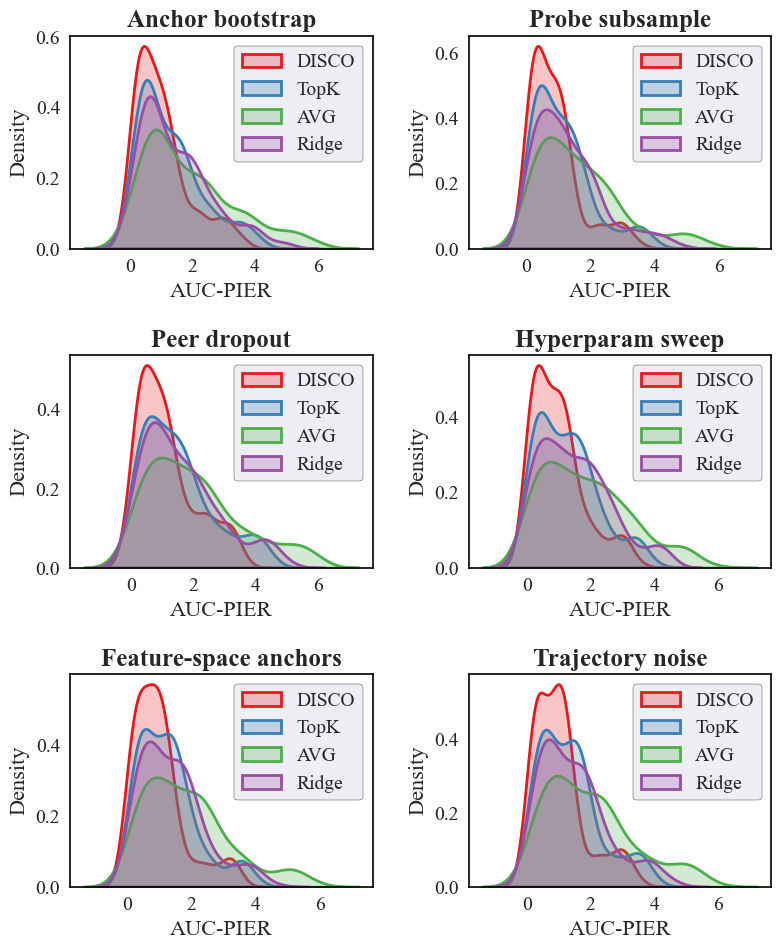

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

USE_KDE = True  # Toggle between KDE and histogram views
HIST_BINS = 25
KDE_BW_METHOD = 'scott'

plt.rcParams['font.family'] = 'Times New Roman'  # Global font

# === Define consistent colors (same scheme as line plots) ===
base_methods = [m for m in METHODS if m != "oracle"]

# Soft colors for histograms/KDE fills
fill_palette = sns.color_palette("Set1", n_colors=len(base_methods))

# Map each method to a color
color_map_fill = {m: c for m, c in zip(base_methods, fill_palette)}

# Special oracle handling
if "oracle" in METHODS:
    color_map_fill["oracle"] = (0.7, 0.7, 0.7)   # light gray

# === Setup subplots ===
n_stressors = len(STRESSORS)
n_cols = min(2, n_stressors)
n_rows = int(np.ceil(n_stressors / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.2 * n_rows), sharey=not USE_KDE)
axes = np.atleast_1d(axes).flatten()

for ax in axes:
    ax.set_facecolor('white')
    # Add frame around the plot
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
        spine.set_color('black')

for ax, stressor in zip(axes, STRESSORS):
    subset = metrics_df[metrics_df['stressor'] == stressor]
    if subset.empty:
        ax.axis('off')
        continue

    for method in METHODS:
        values = subset.loc[subset['method'] == method, 'auc_abs'].dropna()
        if values.empty:
            continue
        color = color_map_fill[method]

        if USE_KDE:
            sns.kdeplot(
                values, ax=ax,
                color=color, label=method,
                fill=True, bw_method=KDE_BW_METHOD,
                lw=2.0, alpha=0.25
            )
        else:
            sns.histplot(
                values, ax=ax,
                color=color, label=method,
                bins=HIST_BINS,
                stat='density', element='step',
                fill=False, linewidth=2.0, alpha=0.85
            )

    ax.set_title(f"{STRESSOR_LABELS.get(stressor, stressor)}", fontsize=18, fontweight='bold')
    ax.set_xlabel('AUC-PIER', fontsize=16)
    ax.set_ylabel('Density', fontsize=16)
    ax.tick_params(axis='both', labelsize=14)
    ax.grid(False)

    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(
            handles, labels,
            fontsize=14, frameon=True,
            framealpha=0.8, edgecolor='black'
        )

# Turn off unused subplots
for ax in axes[n_stressors:]:
    ax.axis('off')

plt.tight_layout(h_pad=2.0, w_pad=2.0)

# Save as PDF (vector format, high quality)
plt.savefig("../pictures/stress_test.pdf", format="pdf", bbox_inches="tight")

plt.show()


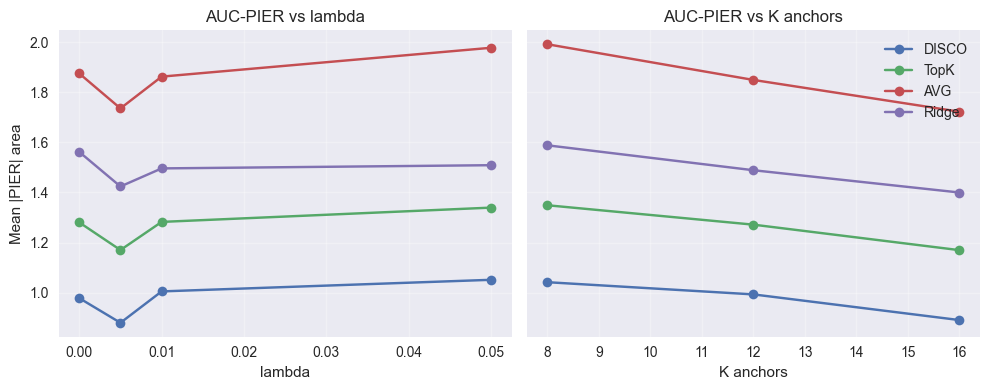

In [61]:
hyper_df = metrics_df[metrics_df['stressor'] == 'hyperparams']
if not hyper_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    lam_summary = hyper_df.groupby(['method', 'lambda']).agg(mean_auc=('auc_abs', 'mean')).reset_index()
    for method in METHODS:
        data = lam_summary[lam_summary['method'] == method]
        if data.empty:
            continue
        axes[0].plot(data['lambda'], data['mean_auc'], marker='o', label=method)
    axes[0].set_title('AUC-PIER vs lambda')
    axes[0].set_xlabel('lambda')
    axes[0].set_ylabel('Mean |PIER| area')
    axes[0].grid(True, alpha=0.3)

    k_summary = hyper_df.groupby(['method', 'K']).agg(mean_auc=('auc_abs', 'mean')).reset_index()
    for method in METHODS:
        data = k_summary[k_summary['method'] == method]
        if data.empty:
            continue
        axes[1].plot(data['K'], data['mean_auc'], marker='o', label=method)
    axes[1].set_title('AUC-PIER vs K anchors')
    axes[1].set_xlabel('K anchors')
    axes[1].grid(True, alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        axes[1].legend(handles, labels, loc='best')
    plt.tight_layout()
    plt.show()
else:
    print('No hyperparameter stressor rows captured.')


In [62]:
ess_table = metrics_df.groupby(['stressor', 'method']).agg(
    ess_mean=('ess', 'mean'),
    ess_std=('ess', 'std'),
    entropy_mean=('entropy', 'mean'),
    entropy_std=('entropy', 'std'),
).reset_index()
print(ess_table)


            stressor method  ess_mean  ess_std  entropy_mean  entropy_std
0   anchor_bootstrap    AVG   11.0000   0.0000        2.3979       0.0000
1   anchor_bootstrap  DISCO    1.1340   0.2834        0.1197       0.2389
2   anchor_bootstrap  Ridge    3.9065   0.9035        1.4876       0.2063
3   anchor_bootstrap   TopK    5.0000   0.0000        1.6094       0.0000
4       anchor_space    AVG   11.0000   0.0000        2.3979       0.0000
5       anchor_space  DISCO    1.0212   0.1195        0.0196       0.1016
6       anchor_space  Ridge    3.8462   0.8548        1.4820       0.1915
7       anchor_space   TopK    5.0000   0.0000        1.6094       0.0000
8        hyperparams    AVG   11.0000   0.0000        2.3979       0.0000
9        hyperparams  DISCO    1.1505   0.3465        0.1286       0.2597
10       hyperparams  Ridge    3.9673   0.9460        1.5068       0.2117
11       hyperparams   TopK    5.0000   0.0000        1.6094       0.0000
12      peer_dropout    AVG   10.0000 

## Next Steps

- Increase GLOBAL_SEEDS or N_REPLICATES_PER_STRESSOR for tighter confidence intervals.
- Swap in production-trained devices to mirror your deployment splits.
- Extend the stressors (e.g., correlated peer dropout, heavier probe noise) and rerun to map out more aggressive failure modes.

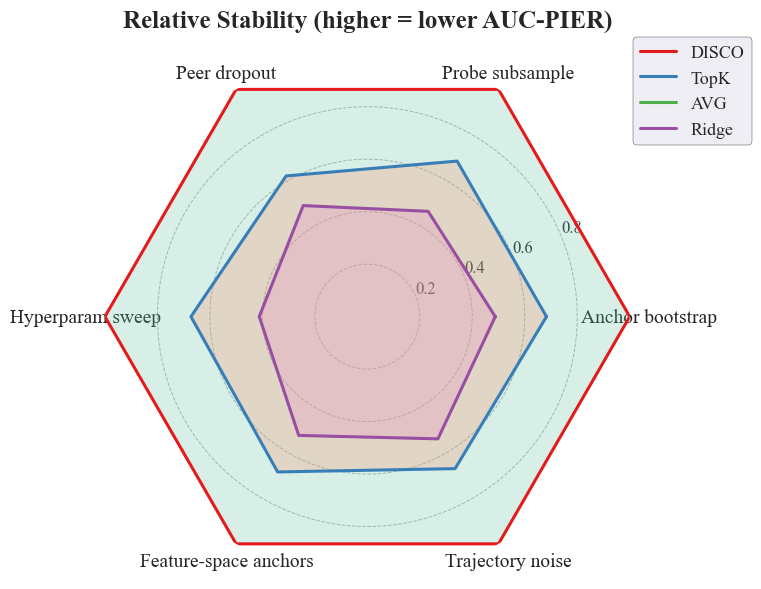

In [102]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Times New Roman'

stressor_order = [
    'anchor_bootstrap',
    'probe_subsample',
    'peer_dropout',
    'hyperparams',
    'anchor_space',
    'trajectory_noise',
]
stressor_labels = [STRESSOR_LABELS[s] for s in stressor_order]

radar_methods = ['DISCO', 'TopK', 'AVG', 'Ridge', 'Oracle']

agg = (
    metrics_df.groupby(['stressor', 'method'])
    .agg(mean_auc=('auc_abs', 'mean'))
    .reset_index()
)

scores, eps = {}, 1e-6
for stressor in stressor_order:
    slab = agg[agg['stressor'] == stressor]
    vals = slab.set_index('method')['mean_auc']
    max_val, min_val = vals.max(), vals.min()
    denom = max(max_val - min_val, eps)
    for method in radar_methods:
        raw = vals.get(method, np.nan)
        if np.isnan(raw):
            score = np.nan
        elif denom <= eps:   # All identical → give full credit
            score = 1.0
        else:
            score = 1.0 - (raw - min_val) / denom
        scores.setdefault(method, []).append(score)

valid_idx = [
    i for i in range(len(stressor_order))
    if not all(np.isnan(scores[m][i]) for m in radar_methods)
]
stressor_labels = [stressor_labels[i] for i in valid_idx]
for method in radar_methods:
    scores[method] = [scores[method][i] for i in valid_idx]

num_axes = len(stressor_labels)
angles = np.linspace(0, 2 * np.pi, num_axes, endpoint=False).tolist()
angles += angles[:1]

line_palette = sns.color_palette('Set1', n_colors=len(radar_methods))
fill_palette = sns.color_palette('Set2', n_colors=len(radar_methods))

fig, ax = plt.subplots(subplot_kw={'polar': True}, figsize=(7, 6))
ax.set_facecolor('white')

for method, line_color, fill_color in zip(radar_methods, line_palette, fill_palette):
    values = np.array(scores[method], dtype=float)
    if np.isnan(values).any():
        continue
    values = np.clip(values, 0.0, 1.0)
    values = np.concatenate([values, values[:1]])
    ax.plot(angles, values, label=method, color=line_color, linewidth=2.2)
    ax.fill(angles, values, color=fill_color, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(stressor_labels, fontsize=14)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8'], fontsize=12)
ax.set_ylim(0, 1.0)
ax.yaxis.grid(True, color='gray', linestyle='--', linewidth=0.7, alpha=0.6)
ax.spines['polar'].set_visible(False)

ax.set_title('Relative Stability (higher = lower AUC-PIER)',
             fontsize=18, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.05),
          frameon=True, framealpha=0.8, edgecolor='black', fontsize=13)

plt.tight_layout()
plt.show()
